# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
# Huang 2018 
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [7]:
best_Elias27 = {'m': -3.297430763696686, 'c': 316115113583956.4, 'l': 44039.6957302716}
best_AS209 = {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}

In [8]:
data =  AS209

In [9]:

dir = "./../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

# Frank Parameters
N = 300

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

# Disk

In [10]:
frank2d.process_vis(uvtable)

Setting gridded data...


In [11]:
print(frank2d.gridded_data['vis'].dtype, type(frank2d.gridded_data['vis']))

complex128 <class 'numpy.ndarray'>


In [12]:
#frank2d.fit(kernel_params = best_params, rtol = 1e-8)

### Power spectrum

In [13]:
max_baseline_50 = Frank2D(50, rout, geom).FT.Qmax
max_baseline_80 = Frank2D(80, rout, geom).FT.Qmax
max_baseline_100 = Frank2D(100, rout, geom).FT.Qmax

In [14]:
# Elias27
params_50_Elias27 = {'m': -3.297430763696686, 'c': 316115113583956.4, 'l': 44039.6957302716}
params_80_Elias27 = {'m': -2.0397167161810477, 'c': 33723199.469468266, 'l': 34841.20905181663}
params_100_Elias27 = {'m': -1.47201355471135, 'c': 19901.175484073883, 'l': 30946.81443034573}

params_50_AS209 = {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}
params_80_AS209 = {'m': -0.5965374600481936, 'c': 0.24061104355821353, 'l': 65964.28945333029}
params_100_AS209 = {'m': -1.1941318661325135, 'c': 456.6510345170579, 'l': 34042.81763475678}

In [15]:
params_50 = params_50_AS209
params_80 = params_80_AS209
params_100 = params_100_AS209

In [16]:
params = {'m': -2, 'c': 1e8, 'l': 7e4}

In [17]:
uvtable_gridded = frank2d.gridded_data

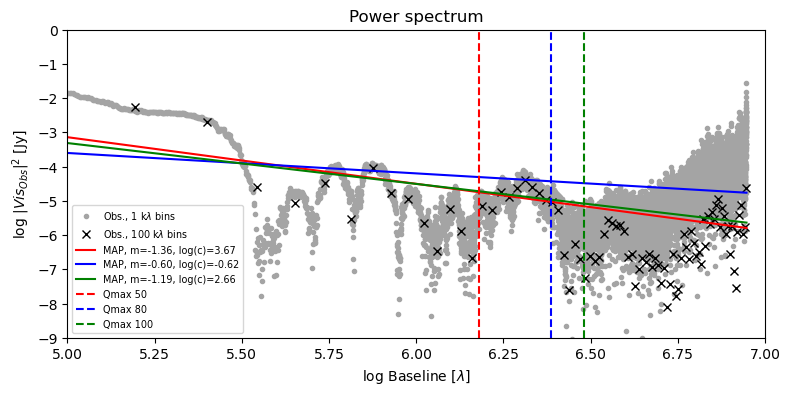

In [18]:
# Plot visibilities gridded.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))

lgy50 = linear_power_spectrum(lgx, params_50['m'], params_50['c'])
lgy80 = linear_power_spectrum(lgx, params_80['m'], params_80['c'])
lgy100 = linear_power_spectrum(lgx, params_100['m'], params_100['c'])

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(9, 4))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.plot(lgx, lgy50, ls='-', color= 'r', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_50['m'], np.log10(params_50['c'])))
plt.plot(lgx, lgy80, ls='-', color= 'blue', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_80['m'], np.log10(params_80['c'])))
plt.plot(lgx, lgy100, ls='-', color= 'green', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_100['m'], np.log10(params_100['c'])))

plt.axvline(np.log10(max_baseline_50), ls='--', color='r', label='Qmax 50')
plt.axvline(np.log10(max_baseline_80), ls='--', color='blue', label='Qmax 80')
plt.axvline(np.log10(max_baseline_100), ls='--', color='green', label='Qmax 100')

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Power spectrum")
plt.ylim(-9, 0)
plt.xlim(5, 7)
plt.show()